In [1]:
import numpy as np 
import matplotlib.pyplot as plt

from time import time

import PyTimeESR
from PyTimeESR import units

In [2]:
eps = -30
U = 100
Bext = np.array([0.1,  0.,  0.3])
Jexch = np.array([3.,3.,3.])
dot = PyTimeESR.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])

Hermiticity check passed!
Hermiticity check passed!


In [3]:
print(dot)

idx 	Occup 	Energy [meV] 	Spin central 	Spin total
				 x,  y,  z 	 x,  y,  z
0	1 	-30.033507190 	-0.2 -0.0 -0.5 	-0.3 -0.0 -0.9
1	1 	-30.009305252 	0.0 0.0 -0.0 	0.0 0.0 0.0
2	1 	-29.996898249 	0.0 0.0 0.0 	0.0 0.0 -0.0
3	1 	-29.960289308 	0.2 0.0 0.5 	0.3 0.0 0.9
4	0 	-0.018304470 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
5	0 	0.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5
6	2 	39.981695530 	0.0 0.0 0.0 	-0.2 -0.0 -0.5
7	2 	40.018304470 	0.0 0.0 0.0 	0.2 0.0 0.5


In [4]:
print('Number of spins:',dot.Nspin)
print('Number of states:',dot.Nstate)
print('Occupancy:',dot.Occupancy)
print('Energies [meV]:', np.round(dot.Energies*units.Hartree,3))
print('Theta [deg]: ', np.round(dot.theta/np.pi*180, 3))
print()

print('Spins states')
print('state, spin site,  <Sx>, <Sy>,  <Sz>')
print(np.round(dot.CalcAllSpin(),3))

Number of spins: 2
Number of states: 8
Occupancy: [1 1 1 1 0 0 2 2]
Energies [meV]: [-3.0034e+01 -3.0009e+01 -2.9997e+01 -2.9960e+01 -1.8000e-02  1.8000e-02
  3.9982e+01  4.0018e+01]
Theta [deg]:  18.435

Spins states
state, spin site,  <Sx>, <Sy>,  <Sz>
[[[ 1.     1.    -0.158 -0.    -0.474]
  [ 1.     2.    -0.158 -0.    -0.474]]

 [[ 2.     1.     0.     0.    -0.   ]
  [ 2.     2.     0.     0.     0.   ]]

 [[ 3.     1.     0.     0.     0.   ]
  [ 3.     2.     0.     0.    -0.   ]]

 [[ 4.     1.     0.158  0.     0.474]
  [ 4.     2.     0.158  0.     0.474]]

 [[ 5.     1.     0.     0.     0.   ]
  [ 5.     2.    -0.158 -0.    -0.474]]

 [[ 6.     1.     0.     0.     0.   ]
  [ 6.     2.     0.158  0.     0.474]]

 [[ 7.     1.     0.     0.     0.   ]
  [ 7.     2.    -0.158 -0.    -0.474]]

 [[ 8.     1.     0.     0.     0.   ]
  [ 8.     2.     0.158  0.     0.474]]]


In [5]:
Del = dot.Delta[:4,:4]*units.Hartree/units.GHz
resonant = np.unique(np.abs(Del))[1:]

print('Delta:')
print(np.round(Del,3))

print('Freqeuncies')
print(f'f1: |g> -> |->: {resonant[0]:.2f} GHz')
print(f'f2: |-> -> |+>: {resonant[1]:.2f} GHz')
print(f'f3: |+> -> |e>: {resonant[2]:.2f} GHz')
print(f'f4: |g> -> |+>: {resonant[3]:.2f} GHz')
print(f'f5: |-> -> |e>: {resonant[4]:.2f} GHz')
print(f'f6: |g> -> |e>: {resonant[5]:.2f} GHz')

Delta:
[[  0.      5.852   8.852  17.704]
 [ -5.852   0.      3.     11.852]
 [ -8.852  -3.      0.      8.852]
 [-17.704 -11.852  -8.852   0.   ]]
Freqeuncies
f1: |g> -> |->: 3.00 GHz
f2: |-> -> |+>: 5.85 GHz
f3: |+> -> |e>: 8.85 GHz
f4: |g> -> |+>: 8.85 GHz
f5: |-> -> |e>: 11.85 GHz
f6: |g> -> |e>: 17.70 GHz


In [6]:
Right = PyTimeESR.Electrode(0,   0, 0.,     5e-3,       1e-1,         4.5,  Nint=1e4, Cutoff=1000)
Left = PyTimeESR.Electrode(-25, 4, 0.5, 1.25e-3, 1e-1, 4.5, Nint=1e4, Cutoff=1000)
frequencies = np.linspace(0.5, 20, 2000)

In [7]:
I0 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies)[:,0]
I1 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=1)[:,1]
I2 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=2)[:,2]
I3 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=3)[:,3]
I4 = PyTimeESR.ESR.ESR(Left, Right, dot, frequencies, NFL=4)[:,4]

In [8]:

I1n = I1 - I1[0]
I2n = I2 - I1   
I4n = I4 - I3   
I3n = I3 - I2   

I1n /= np.max(I1n) - np.min(I1n)
I2n /= np.max(I2n) - np.min(I2n)
I3n /= np.max(I3n) - np.min(I3n)
I4n /= np.max(I4n) - np.min(I4n)

/home/matyas/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'ESR normalized')

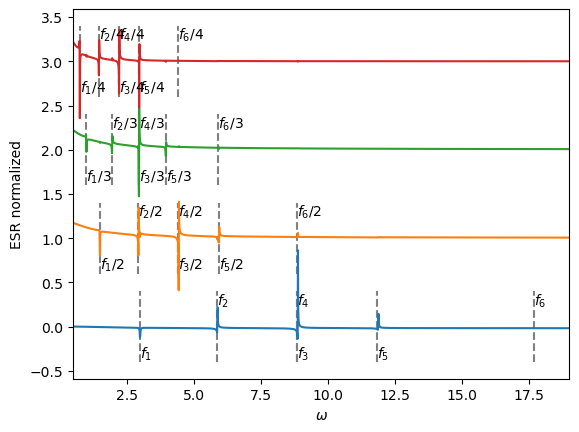

In [48]:
shift = 1

plt.vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
plt.vlines(resonant/2, -.4+1*shift, .4+1*shift, 'gray', '--')
plt.vlines(resonant/3, -.4+2*shift, .4+2*shift, 'gray', '--')
plt.vlines(resonant/4, -.4+3*shift, .4+3*shift, 'gray', '--')

plt.plot(frequencies, I1n+0*shift)
plt.plot(frequencies, I2n+1*shift)
plt.plot(frequencies, I3n+2*shift)
plt.plot(frequencies, I4n+3*shift)

plt.text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
plt.text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
plt.text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
plt.text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
plt.text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
plt.text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.text(resonant[0]/2,1*shift-.2,r'$f_1/2$', ha='left', va='top')
plt.text(resonant[1]/2,1*shift+.2,r'$f_2/2$', ha='left', va='bottom')
plt.text(resonant[2]/2,1*shift-.2,r'$f_3/2$', ha='left', va='top')
plt.text(resonant[3]/2,1*shift+.2,r'$f_4/2$', ha='left', va='bottom')
plt.text(resonant[4]/2,1*shift-.2,r'$f_5/2$', ha='left', va='top')
plt.text(resonant[5]/2,1*shift+.2,r'$f_6/2$',ha='left', va='bottom')

plt.text(resonant[0]/3,2*shift-.2,r'$f_1/3$', ha='left', va='top')
plt.text(resonant[1]/3,2*shift+.2,r'$f_2/3$', ha='left', va='bottom')
plt.text(resonant[2]/3,2*shift-.2,r'$f_3/3$', ha='left', va='top')
plt.text(resonant[3]/3,2*shift+.2,r'$f_4/3$', ha='left', va='bottom')
plt.text(resonant[4]/3,2*shift-.2,r'$f_5/3$', ha='left', va='top')
plt.text(resonant[5]/3,2*shift+.2,r'$f_6/3$', ha='left', va='bottom')

plt.text(resonant[0]/4,3*shift-.2,r'$f_1/4$', ha='left', va='top')
plt.text(resonant[1]/4,3*shift+.2,r'$f_2/4$', ha='left', va='bottom')
plt.text(resonant[2]/4,3*shift-.2,r'$f_3/4$', ha='left', va='top')
plt.text(resonant[3]/4,3*shift+.2,r'$f_4/4$', ha='left', va='bottom')
plt.text(resonant[4]/4,3*shift-.2,r'$f_5/4$', ha='left', va='top')
plt.text(resonant[5]/4,3*shift+.2,r'$f_6/4$', ha='left', va='bottom')

plt.xlim(0.5,19)

plt.xlabel(r'$\omega$')
plt.ylabel(r'ESR normalized')

In [42]:
Jexch_anisopt = np.array([3.,0.,0.])
Bext_2 = np.array([0.3,  0.,  0.1])
dot_two_field = PyTimeESR.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext_2]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch,1,0], ])
dot_anisop = PyTimeESR.QD(-30, 100, np.array([0.5, .5]), np.array([Bext, Bext]), 
        np.array([[2.0, 2.0, 2.0],[2.0, 2.0, 2.0]]),Jexch=[[Jexch_anisopt,1,0], ])

resonant_two_field = np.unique(np.abs(dot_two_field.Delta[:4,:4]))[1:]*units.Hartree/units.GHz
resonant_anisop = np.unique(np.abs(dot_anisop.Delta[:4,:4]))[1:]*units.Hartree/units.GHz

Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!
Hermiticity check passed!


In [29]:
print(resonant_two_field)

[ 3.19199685  6.44413918  9.32704288  9.63613603 12.51903973 18.96317891]


In [43]:
I1_two_field = PyTimeESR.ESR.ESR(Left, Right, dot_two_field, frequencies, NFL=1)[:,1]
I1_anisop = PyTimeESR.ESR.ESR(Left, Right, dot_anisop, frequencies, NFL=1)[:,1]

In [44]:
I1_two_field_n = I1_two_field - I1_two_field[0]
I1_anisop_n = I1_anisop - I1_anisop[0]

I1_two_field_n /= np.max(I1_two_field_n) - np.min(I1_two_field_n)
I1_anisop_n /= np.max(I1_anisop_n) - np.min(I1_anisop_n)

/home/matyas/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/matyas/miniconda3/envs/py312/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


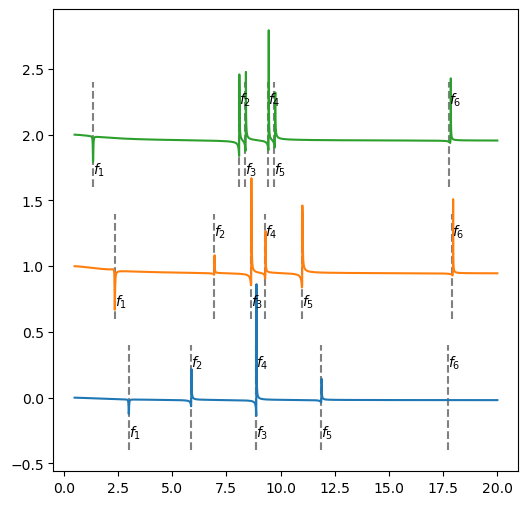

In [47]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax = [ax]

ax[0].vlines(resonant  , -.4+0*shift, .4+0*shift, 'gray', '--')
ax[0].vlines(resonant_two_field, -.4+1*shift, .4+1*shift, 'gray', '--')
ax[0].vlines(resonant_anisop, -.4+2*shift, .4+2*shift, 'gray', '--')

ax[0].plot(frequencies, I1n+0*shift)
ax[0].plot(frequencies, I1_two_field_n+1*shift)
ax[0].plot(frequencies, I1_anisop_n+2*shift)

ax[0].text(resonant[0],0*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant[1],0*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant[2],0*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant[3],0*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant[4],0*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant[5],0*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_two_field[0],1*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_two_field[1],1*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_two_field[2],1*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_two_field[3],1*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_two_field[4],1*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_two_field[5],1*shift+.2,r'$f_6$', ha='left', va='bottom')

ax[0].text(resonant_anisop[0],2*shift-.2,r'$f_1$', ha='left', va='top')
ax[0].text(resonant_anisop[1],2*shift+.2,r'$f_2$', ha='left', va='bottom')
ax[0].text(resonant_anisop[2],2*shift-.2,r'$f_3$', ha='left', va='top')
ax[0].text(resonant_anisop[3],2*shift+.2,r'$f_4$', ha='left', va='bottom')
ax[0].text(resonant_anisop[4],2*shift-.2,r'$f_5$', ha='left', va='top')
ax[0].text(resonant_anisop[5],2*shift+.2,r'$f_6$', ha='left', va='bottom')

plt.show()